In [1]:
# pip install pyusb
import usb.core
import usb.util

# Find all connected USB devices
devices = usb.core.find(find_all=True)

print("Connected USB Devices:")
for dev in devices:
    try:
        # Get manufacturer and product strings if accessible
        manufacturer = usb.util.get_string(dev, dev.iManufacturer)
        product = usb.util.get_string(dev, dev.iProduct)
        print(f"VID: {hex(dev.idVendor)} | PID: {hex(dev.idProduct)} | {manufacturer} - {product}")
    except Exception as e:
        # Some devices block string access without elevated privileges
        print(f"VID: {hex(dev.idVendor)} | PID: {hex(dev.idProduct)} | (Could not read name)")

Connected USB Devices:
VID: 0x2457 | PID: 0x1002 | USB2000 2.41.3 ND3 - NanoDrop Device


In [4]:
import seabreeze
seabreeze.use('pyseabreeze') # Force the python backend

from seabreeze.spectrometers import Spectrometer
import matplotlib.pyplot as plt

try:
    spec = Spectrometer.from_first_available()
    print(f"Found Spectrometer: {spec.model}")
    
    spec.integration_time_micros(10000) 
    wavelengths = spec.wavelengths()
    intensities = spec.intensities()
    
    plt.plot(wavelengths, intensities)
    plt.title("ND1000 Spectrometer Raw Data")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity")
    plt.show()

except Exception as e:
    print(f"Seabreeze error: {e}")

Seabreeze error: No unopened device found.


C:\Users\jordv\AppData\Local\Temp\ipykernel_9488\3566320006.py:2: UserWarning: seabreeze.use has to be called before instantiating a spectrometer
  seabreeze.use('pyseabreeze') # Force the python backend


In [2]:
import usb.core
import usb.util
import time
import struct
import numpy as np

class NanodropND1000:
    VID = 0x2457
    PID = 0x1002
    
    def __init__(self):
        self.dev = None
        self.ep_out = None
        self.ep_in = None
        self.wavelengths = np.linspace(220, 750, 2048)
        self.integration_time_micros = 100000 

    def connect(self):
        # 1. FIND DEVICE
        self.dev = usb.core.find(idVendor=self.VID, idProduct=self.PID)
        if self.dev is None:
            raise RuntimeError("Device not found. Please Unplug/Replug USB.")
        self.dev.set_configuration()
        
        # 2. SET ENDPOINTS
        self.ep_out = 0x02
        self.ep_in = 0x82
        print(f"Connected (OUT:{hex(self.ep_out)} IN:{hex(self.ep_in)})")
        
        # 3. INITIALIZE
        # We send the init command to wake it up
        try:
            self.dev.write(self.ep_out, [0x01])
            time.sleep(0.1)
        except Exception as e:
            print(f"Init Warning: {e}")

    def set_integration_time(self, micros):
        self.integration_time_micros = int(micros)
        payload = struct.pack('<BI', 0x02, self.integration_time_micros)
        self.dev.write(self.ep_out, payload)
        time.sleep(0.05)

    def _flush_buffer(self):
        """Reads until the pipe is empty."""
        try:
            while True:
                self.dev.read(self.ep_in, 512, timeout=20)
        except:
            pass

    def get_spectrum(self):
        # 1. Flush old data
        self._flush_buffer()

        # 2. Request Spectra
        # NO SLEEP HERE! We must catch the data immediately.
        print("Requesting Spectrum...")
        self.dev.write(self.ep_out, [0x09])
        
        # 3. LIVE FILTER READ LOOP
        # We read continuously. We discard tiny packets (status bytes).
        # We keep reading until we have enough "Valid" bytes.
        expected_bytes = 8192
        data_buffer = bytearray()
        
        print("Reading: ", end="", flush=True)
        
        # We use a generous loop because we might be filtering out a lot of garbage
        # or waiting for the integration time.
        start_time = time.time()
        timeout_seconds = 3.0 
        
        while len(data_buffer) < expected_bytes:
            if time.time() - start_time > timeout_seconds:
                print("\n[!] Read Timed Out.")
                break

            try:
                # Read 512 bytes (Standard Packet)
                # Short timeout (100ms) so we can loop fast
                chunk = self.dev.read(self.ep_in, 512, timeout=100)
                
                # --- THE CRITICAL FIX ---
                # 1. Ignore "Status" packets (e.g., 0x69, 0x01)
                # 2. Keep "Data" packets (usually 64 or 512 bytes)
                if len(chunk) < 8: 
                    # We print 's' to show we skipped a glitch packet
                    # print("s", end="", flush=True) 
                    continue 
                
                data_buffer.extend(chunk)
                print(f"+{len(chunk)}", end="", flush=True)
                
            except usb.core.USBTimeoutError:
                # This is normal while the device is "thinking" (integrating light)
                # We just loop again.
                continue
        
        print(f"\nGot {len(data_buffer)} bytes.")
        
        if len(data_buffer) == 0:
            raise RuntimeError("CRITICAL: Device sent 0 bytes. Unplug/Replug required.")

        # 4. DE-INTERLEAVE
        raw_bytes = np.array(data_buffer, dtype=np.uint8)
        
        # Align to 8-byte blocks
        limit = (len(raw_bytes) // 8) * 8
        raw_bytes = raw_bytes[:limit]
        
        # Reshape & Slice (Keep 4 Data, Skip 4 Junk)
        reshaped = raw_bytes.reshape(-1, 8)
        clean_bytes = reshaped[:, 0:4].flatten()
        
        # Convert to Pixels
        if len(clean_bytes) > 4096: clean_bytes = clean_bytes[:4096]
        pixels = clean_bytes.view(dtype=np.uint16)
        
        # Pad Remainder (Prevents Graph Crash)
        if len(pixels) < 2048:
            print(f"Padding {2048 - len(pixels)} pixels...")
            pad_val = pixels[-1] if len(pixels) > 0 else 0
            pixels = np.pad(pixels, (0, 2048 - len(pixels)), constant_values=pad_val)

        return self.wavelengths, pixels

    # --- AUTONOMOUS CONTROL (EXPERIMENTAL) ---
    
    def open_arm(self):
        """Attempts to open the arm (Magnet Off / Motor Up)."""
        print("Command: Open Arm")
        # GPIO High/Low logic is a guess, usually one bit controls direction, one controls power.
        # Try turning OFF GPIO 0 and 1
        self.dev.write(self.ep_out, [0x6A, 0x00, 0x00]) # GPIO Write: All Off
        time.sleep(0.5)

    def close_arm(self):
        """Attempts to close the arm (Magnet On / Motor Down)."""
        print("Command: Close Arm")
        # Try turning ON GPIO 0 (Bit 0 = 0x01)
        self.dev.write(self.ep_out, [0x6A, 0x00, 0x01]) 
        time.sleep(0.5)

    def flash_lamp(self):
        """Triggers a single Xenon flash."""
        print("Command: Flash Lamp")
        # Standard Ocean Optics Strobe Trigger
        self.dev.write(self.ep_out, [0x03, 0x01]) # Strobe ON
        time.sleep(0.01) # 10ms pulse
        self.dev.write(self.ep_out, [0x03, 0x00]) # Strobe OFF
    
    def close(self):
        usb.util.dispose_resources(self.dev)

In [3]:
import matplotlib.pyplot as plt

# Instantiate the machine
nd = NanodropND1000()

try:
    # 1. Connect
    print("Attempting to connect...")
    nd.connect()
    
    # 2. Test Actuators (Listen carefully!)
    print("\n--- Testing Hardware ---")
    print("Listen for a click (Arm Open)...")
    nd.open_arm()
    time.sleep(1.5)
    
    print("Listen for a click (Arm Close)...")
    nd.close_arm()
    time.sleep(1.5)
    
    print("Look for a flash (Lamp)...")
    nd.flash_lamp()
    time.sleep(0.5)
    
    # 3. Test Spectrometer
    print("\n--- Testing Spectrometer ---")
    nd.set_integration_time(100000) # 100ms integration
    wavelengths, pixels = nd.get_spectrum()
    
    # 4. Plot the results
    print("\nPlotting Data...")
    plt.figure(figsize=(10, 5))
    plt.plot(wavelengths, pixels, color='blue')
    plt.title("NanoDrop 1000 - Raw PyUSB Spectrum Test")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Raw Pixel Intensity")
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"\n[ERROR]: {e}")
finally:
    nd.close()
    print("\nConnection closed safely.")

Attempting to connect...
Connected (OUT:0x2 IN:0x82)

--- Testing Hardware ---
Listen for a click (Arm Open)...
Command: Open Arm
Listen for a click (Arm Close)...
Command: Close Arm
Look for a flash (Lamp)...
Command: Flash Lamp

--- Testing Spectrometer ---
Requesting Spectrum...
Reading: 
[ERROR]: [Errno None] b'libusb0-dll:err [_usb_reap_async] timeout error\n'

Connection closed safely.


In [4]:
import usb.core
import time

dev = usb.core.find(idVendor=0x2457, idProduct=0x1002)
if dev is None:
    raise ValueError("NanoDrop not found. (Check Zadig!)")

dev.set_configuration()
ep_out = 0x02 

try:
    print("1. Sending 0x08 (Wake/Trigger Mode)...")
    dev.write(ep_out, [0x08])
    time.sleep(3) 
    
    print("2. Sending 0x01 (Initialize)...")
    dev.write(ep_out, [0x01])
    time.sleep(3)
    
    print("3. Sending 0x03 0xFF (Turning Lamp ON)... listen for the cricket!")
    dev.write(ep_out, [0x03, 0xFF])
    time.sleep(3) # The cricket should chirp for exactly 3 seconds
    
    print("4. Sending 0x03 0x00 (Turning Lamp OFF)...")
    dev.write(ep_out, [0x03, 0x00]) # This should kill the cricket
    time.sleep(1)

    print("ENGAGING ELECTROMAGNET (0x0F 0xFF)... Listen for a clack!")
    dev.write(ep_out, [0x0F, 0xFF])
    time.sleep(2) # Hold it for 2 seconds
    
    print("RELEASING ELECTROMAGNET (0x0F 0x00)... Listen for release!")
    dev.write(ep_out, [0x0F, 0x00])
    time.sleep(1)
    
    print("Test complete.")

except Exception as e:
    print(f"Failed: {e}")
finally:
    import usb.util
    usb.util.dispose_resources(dev)

1. Sending 0x08 (Wake/Trigger Mode)...
2. Sending 0x01 (Initialize)...
3. Sending 0x03 0xFF (Turning Lamp ON)... listen for the cricket!
4. Sending 0x03 0x00 (Turning Lamp OFF)...
ENGAGING ELECTROMAGNET (0x0F 0xFF)... Listen for a clack!
RELEASING ELECTROMAGNET (0x0F 0x00)... Listen for release!
Test complete.


In [2]:
import usb.core
import usb.util
import time

# --- Configuration ---
VID = 0x2457
PID = 0x1002
EP_OUT = 0x02 # PC -> NanoDrop (Commands)
EP_IN = 0x82  # NanoDrop -> PC (Data)

def get_device():
    print("Finding NanoDrop...")
    dev = usb.core.find(idVendor=VID, idProduct=PID)
    if dev is None:
        raise ValueError("NanoDrop not found. (Check Zadig!)")
    
    dev.set_configuration()
    
    # CRITICAL FIX: Forcefully reset the endpoints in case they were stalled
    dev.clear_halt(EP_OUT)
    dev.clear_halt(EP_IN)
    return dev

def run_test():
    dev = get_device()
    
    try:
        print("\n--- 1. INITIALIZATION ---")
        dev.write(EP_OUT, [0x08]) # Wake / Clear
        time.sleep(0.1)
        dev.write(EP_OUT, [0x01]) # Initialize
        time.sleep(0.5)
        
        print("\n--- 2. EXTRACTING DNA (COEFFICIENTS) ---")
        # Ask for Wavelength Coefficient 0
        dev.write(EP_OUT, [0x05, 0x01]) 
        
        # CRITICAL FIX: Give the machine 50ms to fetch the data from memory
        time.sleep(0.05) 
        
        # Read EXACTLY 17 bytes (Ocean Optics standard response length for this command)
        response = dev.read(EP_IN, 17, timeout=2000)
        
        # The first byte is an echo (0x05), the second is the index (0x01), the rest is ASCII text
        coeff_string = bytearray(response[2:]).decode('ascii').strip('\x00')
        print(f"Success! Coefficient 0 from memory: {coeff_string}")

        print("\n--- 3. MINI MEASUREMENT CYCLE ---")
        # Set Integration Time to 20ms
        dev.write(EP_OUT, [0x02, 0x14, 0x00])
        print("Integration time set to 20ms.")
        
        # Magnet ON (0.2mm) and Lamp ON (Max)
        dev.write(EP_OUT, [0x0F, 0xFF])
        dev.write(EP_OUT, [0x03, 0xFF])
        print("Magnet Clacked. Lamp Fired.")
        time.sleep(0.1) # Let the light stabilize
        
        # Request Spectrum
        dev.write(EP_OUT, [0x09])
        time.sleep(0.05) # Give it time to take the picture
        
        print("Requested Spectrum. Reading first data chunk...")
        
        # Grab the first 512 bytes of the raw spectrum data
        raw_data = dev.read(EP_IN, 512, timeout=2000)
        print(f"Got {len(raw_data)} bytes of raw pixel data!")
        print(f"Snippet of raw hex: {[hex(x) for x in raw_data[:10]]}")

    except usb.core.USBError as e:
        print(f"\n[USB ERROR] {e}")
    finally:
        # Turn everything off safely
        try:
            dev.write(EP_OUT, [0x03, 0x00]) # Lamp OFF
            dev.write(EP_OUT, [0x0F, 0x00]) # Magnet OFF
            print("Hardware safely powered down.")
        except:
            pass # If it's locked, just let it go
            
        usb.util.dispose_resources(dev)
        print("\nConnection closed.")

# Execute the test
if __name__ == "__main__":
    run_test()

Finding NanoDrop...

--- 1. INITIALIZATION ---

--- 2. EXTRACTING DNA (COEFFICIENTS) ---

[USB ERROR] [Errno None] b'libusb0-dll:err [_usb_reap_async] reaping request failed, win error: A device attached to the system is not functioning.\r\n\n'
Hardware safely powered down.

Connection closed.


In [1]:
import usb.core
import time

dev = usb.core.find(idVendor=0x2457, idProduct=0x1002)
if dev is None:
    raise ValueError("NanoDrop not found. (Check Zadig!)")

dev.set_configuration()
ep_out = 0x02 # Mailbox for commands
ep_in = 0x82  # Mailbox for data

try:
    print("1. Waking up and Initializing...")
    dev.write(ep_out, [0x08])
    time.sleep(0.1)
    dev.write(ep_out, [0x01])
    time.sleep(0.2)
    
    # Safely try to flush any old garbage data out of the pipe
    try:
        dev.read(ep_in, 64, timeout=50)
    except:
        pass # If it times out here, it just means the pipe is already clean

    print("\n2. Asking for Coefficient 1 (Command: 0x05, 0x01)...")
    dev.write(ep_out, [0x05, 0x01])
    
    # CRITICAL: Let the machine think before we try to read!
    time.sleep(0.05) 
    
    print("3. Listening for the reply...")
    # Read exactly 64 bytes (the native USB hardware packet size for this era)
    # Generous 2-second timeout so Windows doesn't panic
    data = dev.read(ep_in, 64, timeout=2000) 
    
    print("\n--- SUCCESS! WE GOT DATA ---")
    print(f"Raw Bytes: {data}")
    
    # The first two bytes are usually an echo. The rest is ASCII text.
    text = bytearray(data[2:]).decode('ascii', errors='ignore').strip('\x00')
    print(f"Decoded Coefficient: {text}")

except Exception as e:
    print(f"\n[FAILED]: {e}")
finally:
    import usb.util
    usb.util.dispose_resources(dev)
    print("Test complete. Device released.")

1. Waking up and Initializing...

2. Asking for Coefficient 1 (Command: 0x05, 0x01)...
3. Listening for the reply...

--- SUCCESS! WE GOT DATA ---
Raw Bytes: array('B', [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
Decoded Coefficient: 
Test complete. Device released.


In [2]:
import usb.core
import time

dev = usb.core.find(idVendor=0x2457, idProduct=0x1002)
if dev is None:
    raise ValueError("NanoDrop not found. (Check Zadig!)")

dev.set_configuration()

ep_out = 0x02       # Commands OUT
ep_in_heavy = 0x82  # Spectrum IN (4.1.2)
ep_in_comm = 0x87   # Text/Status IN (4.1.7) <-- YOUR DISCOVERY!

try:
    print("1. Waking up...")
    dev.write(ep_out, [0x08])
    time.sleep(0.1)
    dev.write(ep_out, [0x01])
    time.sleep(0.2)
    
    print("2. Asking for Coefficient 1 (Command: 0x05, 0x01)...")
    dev.write(ep_out, [0x05, 0x01])
    
    # We don't even need a big delay now, because we are looking in the right box!
    time.sleep(0.05) 
    
    print(f"3. Listening on Endpoint {hex(ep_in_comm)}...")
    
    # Read from Endpoint 7!
    data = dev.read(ep_in_comm, 64, timeout=1000) 
    
    print("\n--- BINGO! WE GOT DATA ---")
    print(f"Raw Bytes: {data}")
    
    # Decode it (ignoring the 2-byte echo header)
    text = bytearray(data[2:]).decode('ascii', errors='ignore').strip('\x00')
    print(f"Decoded Coefficient: {text}")

except Exception as e:
    print(f"\n[FAILED]: {e}")
finally:
    dev.reset() 
    import usb.util
    usb.util.dispose_resources(dev)
    print("\nDevice cleanly released.")

1. Waking up...
2. Asking for Coefficient 1 (Command: 0x05, 0x01)...
3. Listening on Endpoint 0x87...

--- BINGO! WE GOT DATA ---
Raw Bytes: array('B', [5, 1, 49, 46, 55, 55, 52, 48, 50, 53, 101, 43, 48, 48, 50, 0, 54])
Decoded Coefficient: 1.774025e+002 6

Device cleanly released.


In [3]:
import usb.core
import time

dev = usb.core.find(idVendor=0x2457, idProduct=0x1002)
if dev is None:
    raise ValueError("NanoDrop not found. (Check Zadig!)")

dev.set_configuration()
ep_out = 0x02
ep_in_comm = 0x87 # Endpoint 7!

try:
    print("Waking up...")
    dev.write(ep_out, [0x08])
    time.sleep(0.1)
    dev.write(ep_out, [0x01])
    time.sleep(0.2)
    
    coefficients = []
    
    print("\n--- Downloading Factory Calibration ---")
    # Ocean Optics uses indexes 1, 2, 3, and 4 for the wavelength polynomial
    for i in range(1, 5):
        dev.write(ep_out, [0x05, i])
        time.sleep(0.05)
        
        data = dev.read(ep_in_comm, 64, timeout=500)
        
        # PROPER C-STRING DECODE: Split at the \x00 null terminator and take the first part!
        raw_string = bytearray(data[2:]).decode('ascii', errors='ignore').split('\x00')[0]
        
        # Convert it to a real Python float
        coeff_value = float(raw_string)
        coefficients.append(coeff_value)
        
        print(f"Index {i} (C{i-1}): {coeff_value}")

except Exception as e:
    print(f"\n[FAILED]: {e}")
finally:
    dev.reset() 
    import usb.util
    usb.util.dispose_resources(dev)
    print("\nDevice cleanly released.")

Waking up...

--- Downloading Factory Calibration ---
Index 1 (C0): 177.4025
Index 2 (C1): 0.3825275
Index 3 (C2): -1.53782e-05
Index 4 (C3): -2.12388e-09

Device cleanly released.


1. Waking up...
2. Setting Integration Time to 20ms...
3. Turning on Lamp and Magnet...
4. Requesting Spectrum (0x09)...
   Reading packets: ................................................................
   Total bytes read: 4096
5. Turning hardware off...
6. Decoding and Plotting...


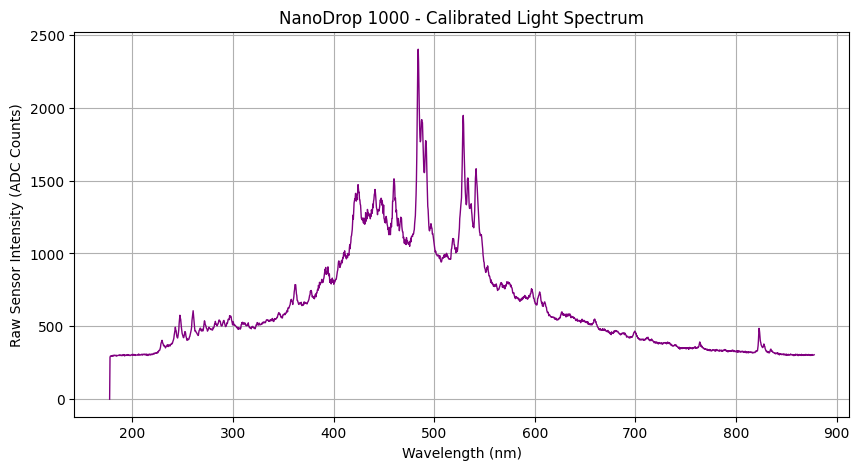

Device released.


In [ ]:
import usb.core
import usb.util
import time
import numpy as np
import matplotlib.pyplot as plt

# Your machine's specific DNA!
C0,C1,C2,C3 = coefficients

def get_calibrated_wavelengths():
    """Calculates the true X-axis using your machine's polynomial."""
    pixels = np.arange(2048)
    wavelengths = C0 + (C1 * pixels) + (C2 * (pixels**2)) + (C3 * (pixels**3))
    return wavelengths

def decode_ocean_optics_payload(raw_bytes):
    """Reconstructs the weird 64-LSB / 64-MSB packet structure."""
    pixels = []
    # Loop through the array in 128-byte chunks (64 LSBs + 64 MSBs)
    for i in range(0, 4096, 128):
        lsb_block = raw_bytes[i : i+64]
        msb_block = raw_bytes[i+64 : i+128]
        
        # Stitch them together
        for j in range(64):
            val = (msb_block[j] << 8) | lsb_block[j]
            pixels.append(val)
            
    return np.array(pixels)

# --- HARDWARE EXECUTION ---
dev = usb.core.find(idVendor=0x2457, idProduct=0x1002)
if dev is None:
    raise ValueError("NanoDrop not found. (Check Zadig!)")

dev.set_configuration()
ep_out = 0x02
ep_in_heavy = 0x82 # Mailbox for the massive spectrum data!

dev.clear_halt(ep_out)
dev.clear_halt(ep_in_heavy)

try:
    print("1. Waking up...")
    dev.write(ep_out, [0x08])
    time.sleep(0.1)
    dev.write(ep_out, [0x01])
    time.sleep(0.2)
    
    print("2. Setting Integration Time to 20ms...")
    dev.write(ep_out, [0x02, 0x14, 0x00])
    
    print("3. Turning on Lamp and Magnet...")
    dev.write(ep_out, [0x0F, 0xFF]) # Magnet
    dev.write(ep_out, [0x03, 0xFF]) # Lamp
    time.sleep(0.2) # Let the light stabilize
    
    # Flush any old junk out of the heavy mailbox
    try:
        while True:
            dev.read(ep_in_heavy, 512, timeout=50)
    except:
        pass
    
    print("4. Requesting Spectrum (0x09)...")
    dev.write(ep_out, [0x09])
    
    # We need to read exactly 4096 bytes (plus maybe a 1 byte sync packet)
    # The manual says data comes in 64-byte packets. 64 packets * 64 bytes = 4096.
    data_buffer = bytearray()
    
    print("   Reading packets: ", end="")
    for _ in range(64): # Read exactly 64 packets
        chunk = dev.read(ep_in_heavy, 64, timeout=1000)
        data_buffer.extend(chunk)
        print(".", end="")
        
    print(f"\n   Total bytes read: {len(data_buffer)}")
    
    print("5. Turning hardware off...")
    dev.write(ep_out, [0x03, 0x00]) # Lamp
    dev.write(ep_out, [0x0F, 0x00]) # Magnet
    
    print("6. Decoding and Plotting...")
    wavelengths = get_calibrated_wavelengths()
    intensities = decode_ocean_optics_payload(data_buffer)
    
    # According to the manual, pixels 26 to 2074 (which translates to index 26 to 2047) are the active ones.
    # We'll plot the whole thing, but you'll notice the first 25 pixels might be flat/dark noise.
    plt.figure(figsize=(10, 5))
    plt.plot(wavelengths, intensities, color='purple', linewidth=1)
    plt.title("NanoDrop 1000 - Calibrated Light Spectrum")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Raw Sensor Intensity (ADC Counts)")
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"\n[FAILED]: {e}")
finally:
    dev.reset() 
    import usb.util
    usb.util.dispose_resources(dev)
    print("Device released.")

In [5]:
print(data_buffer)

bytearray(b'\x00 ())&)(\'.**..+,-)-),,,-/-/+/./-*.0,12/)0.,-01-2,/1/.+,///14.3/3\x00\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01202,////.0316.00/0324040446304155-33,12623/2624236:95<<<=;?;>C?H\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01HOOQ[f|\x86\x8d\x94\x8a\x7f{osmng`fklqvritnrrmywxy\x80~\x88\x90\x97\xa2\xb8\xc6\xd8\xee\xdb\xd7\xbf\xaf\xa7\xa4\xb2\xc8\xda\x07"@.%\x04\xec\xd4\xc2\xbb\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\